# 📧 Phishing Email Detection
This notebook builds a machine learning pipeline to classify emails as **Ham (0)** or **Phishing (1)** using the CEAS_08 dataset.  
Pipeline: Data Preparation → EDA → Feature Engineering → Model Training → Evaluation → Prediction Demo

## 1. Imports

In [ ]:
# Data Preparation
import numpy as np
import math
import pandas as pd

# EDA
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from scipy.sparse import hstack
import scipy

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('All libraries loaded ✓')

All libraries loaded ✓


## 2. Load Data

In [ ]:
df2 = pd.read_csv("/content/data/CEAS_08.csv")
df1 = pd.read_csv("/content/data/SpamAssasin.csv")

In [ ]:
df2.sample(5)

,sender,receiver,date,subject,body,label,urls
34352,Marietta Ouellette <BertaplayroomLassiter@marc...,"bethany.o.seavey@gvc.ceas-challenge.cc, user8....","Fri, 08 Aug 2008 01:34:03 +0600",Replica Classics trendy replica watches for yo...,\nThey look and feel exactly like the real thi...,1,1
8597,Clinton Lee Taylor <slanqeyapw.wgqhdj@gmail.com>,kpitck-aew45@python.org,"Wed, 06 Aug 2008 07:44:52 +0200",[python-win32] OE/WAB help with VB ...,Greetings ...\n\n I hope I might be able to ge...,0,1
464,kenmiles <unhhquj@kmiles.co.uk>,bspsggvwcfmo-bvbmb@lists.sourceforge.net,"Tue, 05 Aug 2008 15:56:39 -0800",[SM-USERS] Autorespond plugin,\nI am using squirrelmail 1.4.13 with Dovecote...,0,1
16266,Josephine Flanagan <lveblessed@awapatent.com>,user2.2@gvc.ceas-challenge.cc,"Sat, 02 Aug 2008 15:08:14 -0500",You don`t forget it,\n\n\nAdd more fire to your relations.\n\n\nLe...,1,0
17674,Gale Hope <dwvoiceofastrologym@voiceofastrolog...,user7-ext4@gvc.ceas-challenge.cc,"Wed, 06 Aug 2008 19:06:39 -0300",Quality medications can be cheap!,\nCanadian Pharmacy offers a time and money sa...,1,1


In [ ]:
df1.sample(5)

,sender,receiver,date,subject,body,label,urls
3731,Brian Fahrlander <kilroy@kamakiriad.com>,rpm-zzzlist@freshrpms.net,"Wed, 21 Aug 2002 04:08:52 -0500","Re: advice on 7.3.92 to 7.3.93, and Apt compiling","On Wed, 21 Aug 2002 10:38:04 +0200, Matthias S...",0,1
1929,"""hyatt@mozilla"" <rssfeeds@spamassassin.taint.org>",yyyy@spamassassin.taint.org,"Thu, 26 Sep 2002 15:27:49 -0000",Validation,URL: http://www.mozillazine.org/weblogs/hyatt/...,0,1
334,"""Joseph S. Barrera III"" <joe@barrera.org>",fork@spamassassin.taint.org,"Mon, 26 Aug 2002 18:30:45 -0700",Re: The GOv gets tough on Net Users.....er Pir...,Adam L. Beberg wrote:\n > Forwarding me stuff ...,0,0
2520,"""Breathnach, Proinnsias (Dublin)"" <breatpro@ex...",social@linux.ie,"Wed, 7 Aug 2002 10:00:11 +0100",RE: [ILUG-Social] Online Bookstores,What's wrong with good ol' www.eason.ie ?\n\nD...,0,1
867,Gary Lawrence Murphy <garym@canada.com>,"""R. A. Hettinga"" <rah@shipwright.com>",03 Oct 2002 10:41:29 -0400,Re: Apple Sauced...again,">>>>> ""R"" == R A Hettinga writes: R> ""Whe...",0,1


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39154 non-null  object
 1   receiver  38692 non-null  object
 2   date      39154 non-null  object
 3   subject   39126 non-null  object
 4   body      39154 non-null  object
 5   label     39154 non-null  int64 
 6   urls      39154 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5809 entries, 0 to 5808
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    5809 non-null   object
 1   receiver  5599 non-null   object
 2   date      5809 non-null   object
 3   subject   5793 non-null   object
 4   body      5808 non-null   object
 5   label     5809 non-null   int64 
 6   urls      5809 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 317.8+ KB


Label counts:
label
Phishing    21842
Ham         17312
Name: count, dtype: int64


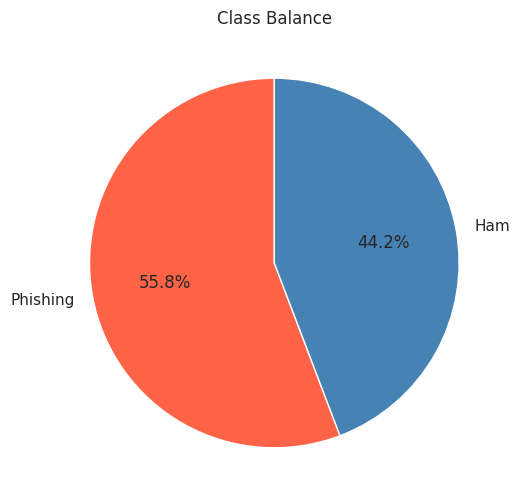

In [ ]:
label_counts = df2['label'].value_counts()
print('Label counts:')
print(label_counts.rename({0: 'Ham', 1: 'Phishing'}))

plt.figure(figsize=(6, 6))

plt.pie(
    label_counts,
    labels=['Phishing', 'Ham'],
    autopct='%1.1f%%',
    colors=['tomato', 'steelblue'],
    startangle=90
)

plt.title('Class Balance')

plt.show()

Label counts:
label
Ham         4091
Phishing    1718
Name: count, dtype: int64


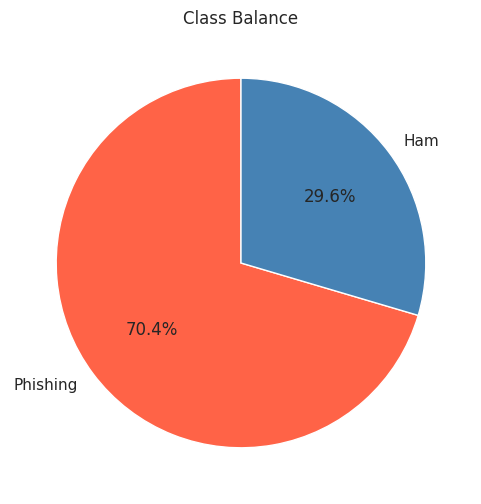

In [ ]:
label_counts = df1['label'].value_counts()
print('Label counts:')
print(label_counts.rename({0: 'Ham', 1: 'Phishing'}))

plt.figure(figsize=(6, 6))

plt.pie(
    label_counts,
    labels=['Phishing', 'Ham'],
    autopct='%1.1f%%',
    colors=['tomato', 'steelblue'],
    startangle=90
)

plt.title('Class Balance')

plt.show()

In [ ]:
ham_df = df1[df1['label'] == 0]
df = pd.concat([df2, ham_df], ignore_index=True)

df.to_csv("phishingEmail.csv", index=False)

## 3. Data Cleaning

In [ ]:
# Drop receiver — too many nulls and not a useful signal
df.drop('receiver', axis=1, inplace=True)
print('Dropped `receiver` column.')

Dropped `receiver` column.


In [ ]:
df.shape

(43245, 6)

In [ ]:
df.isna().sum()

,0
sender,0
date,0
subject,32
body,0
label,0
urls,0


In [ ]:
# Drop rows where subject is missing (only 28 rows)
df = df.dropna(subset=["subject"])
print(f'Shape after dropping null subjects: {df.shape}')

Shape after dropping null subjects: (43213, 6)


In [ ]:
df.isnull().sum()

,0
sender,0
date,0
subject,0
body,0
label,0
urls,0


In [ ]:
df.head()

,sender,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


## 4. Exploratory Data Analysis (EDA)

Label counts:
label
Phishing    21829
Ham         21384
Name: count, dtype: int64


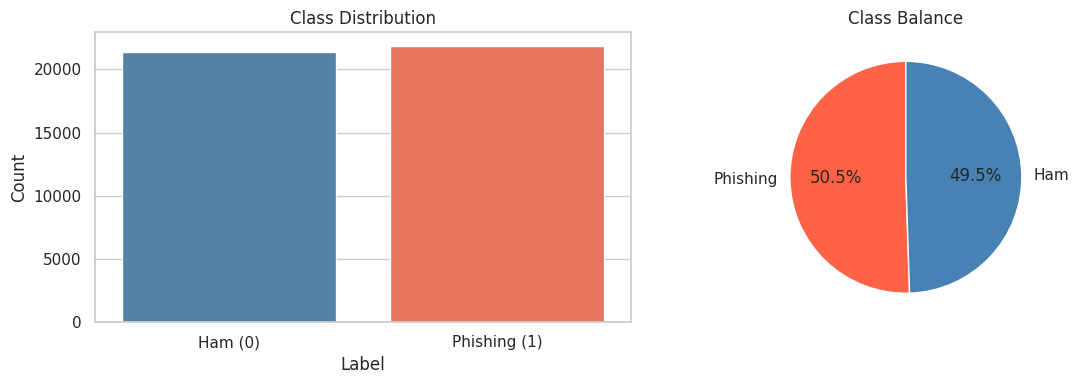

In [ ]:
# --- 4.1 Class Distribution ---
label_counts = df['label'].value_counts()
print('Label counts:')
print(label_counts.rename({0: 'Ham', 1: 'Phishing'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='label', data=df, palette=['steelblue', 'tomato'], ax=axes[0])
axes[0].set_xticklabels(['Ham (0)', 'Phishing (1)'])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(label_counts, labels=['Phishing', 'Ham'], autopct='%1.1f%%',
            colors=['tomato', 'steelblue'], startangle=90)
axes[1].set_title('Class Balance')

plt.tight_layout()
plt.show()

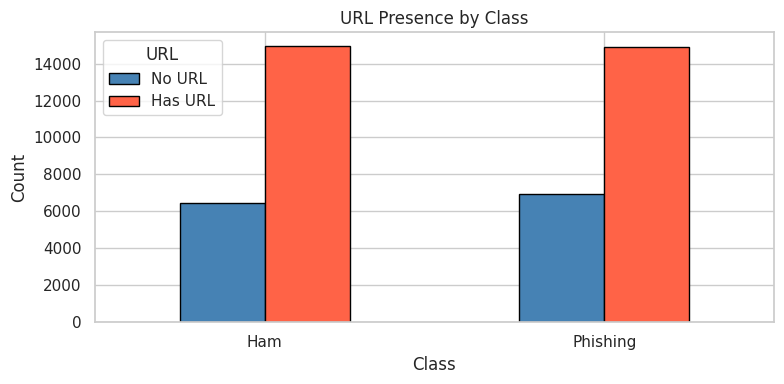

In [ ]:
# --- 4.2 URL flag distribution by label ---
url_by_label = df.groupby(['label', 'urls']).size().unstack(fill_value=0)
url_by_label.index = ['Ham', 'Phishing']
url_by_label.columns = ['No URL', 'Has URL']

url_by_label.plot(kind='bar', figsize=(8, 4), color=['steelblue', 'tomato'], edgecolor='black')
plt.title('URL Presence by Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='URL')
plt.tight_layout()
plt.show()



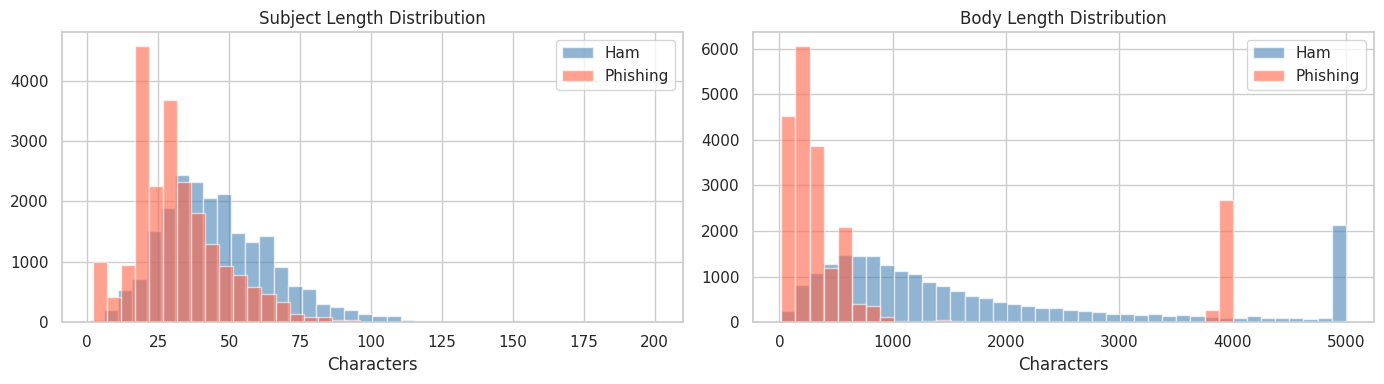

          subject_len     body_len
label                             
Ham         45.923027  2447.554386
Phishing    31.633149   801.668423


In [ ]:
# --- 4.3 Text-length distributions ---
df['subject_len'] = df['subject'].str.len()
df['body_len'] = df['body'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color, name in [(0, 'steelblue', 'Ham'), (1, 'tomato', 'Phishing')]:
    axes[0].hist(df[df['label']==label]['subject_len'].clip(upper=200),
                 bins=40, alpha=0.6, color=color, label=name)
    axes[1].hist(df[df['label']==label]['body_len'].clip(upper=5000),
                 bins=40, alpha=0.6, color=color, label=name)

axes[0].set_title('Subject Length Distribution')
axes[0].set_xlabel('Characters')
axes[0].legend()

axes[1].set_title('Body Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].legend()

plt.tight_layout()
plt.show()

print(df.groupby('label')[['subject_len','body_len']].mean().rename(index={0:'Ham',1:'Phishing'}))

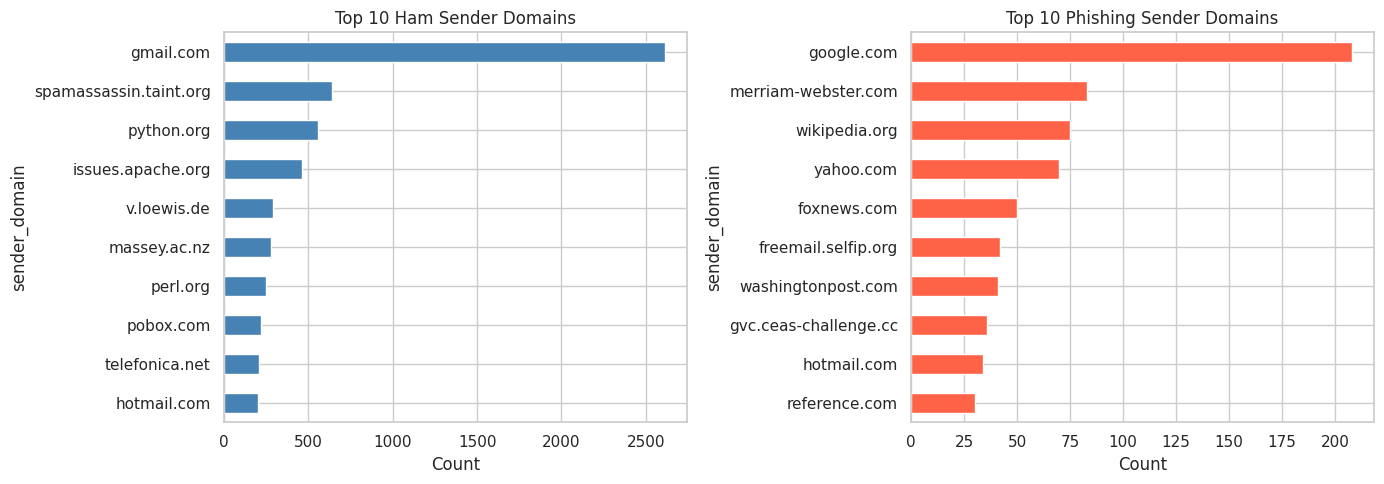

In [ ]:
# --- 4.4 Top sender domains ---
df['sender_domain'] = df['sender'].str.extract(r'@([\w.\-]+)', expand=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label, title, color in [
    (axes[0], 0, 'Top 10 Ham Sender Domains', 'steelblue'),
    (axes[1], 1, 'Top 10 Phishing Sender Domains', 'tomato')
]:
    top_domains = df[df['label']==label]['sender_domain'].value_counts().head(10)
    top_domains.plot(kind='barh', ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [ ]:
# --- 5.1 Text cleaning helper ---
def clean_text(text: str) -> str:
    """Lowercase, remove HTML tags, URLs, and extra whitespace."""
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # strip HTML
    text = re.sub(r'http\S+|www\.\S+', ' url ', text)  # replace URLs
    text = re.sub(r'[^a-z\s]', ' ', text)          # keep letters only
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Combine subject + body into one field for TF-IDF
df['text'] = (df['subject'].fillna('') + ' ' + df['body'].fillna('')).apply(clean_text)
print('Sample cleaned text:')
print(df['text'].iloc[0][:300])

Sample cleaned text:
never agree to be a loser buck up your troubles caused by small dimension will soon be over become a lover no woman will be able to resist url come even as nazi tanks were rolling down the streets the dreamersphilosopher or a journalist he was still not sure i do the same


In [ ]:
# --- 5.2 Numerical / structural features ---
df['subject_len']        = df['subject'].str.len()
df['body_len']           = df['body'].str.len()
df['subject_word_count'] = df['subject'].str.split().str.len()
df['body_word_count']    = df['body'].str.split().str.len()
df['exclamation_count']  = df['body'].str.count('!')
df['dollar_count']       = df['body'].str.count(r'\$')
df['caps_ratio']         = df['body'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)
COMMON_DOMAINS = {'gmail.com','yahoo.com','hotmail.com','outlook.com','aol.com','live.com'}
df['is_common_domain']   = df['sender_domain'].isin(COMMON_DOMAINS).astype(int)

NUM_FEATURES = [
    'urls', 'subject_len', 'body_len', 'subject_word_count',
    'body_word_count', 'exclamation_count', 'dollar_count',
    'caps_ratio', 'is_common_domain'
]
print('Numerical features created:', NUM_FEATURES)

Numerical features created: ['urls', 'subject_len', 'body_len', 'subject_word_count', 'body_word_count', 'exclamation_count', 'dollar_count', 'caps_ratio', 'is_common_domain']


In [ ]:
# --- 5.3 VIF check for multicollinearity among numerical features ---
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_num_df = df[NUM_FEATURES].fillna(0)
vif_data = pd.DataFrame({
    'Feature': NUM_FEATURES,
    'VIF': [variance_inflation_factor(X_num_df.values, i) for i in range(len(NUM_FEATURES))]
})
print('VIF (values > 10 suggest multicollinearity):')
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

VIF (values > 10 suggest multicollinearity):
           Feature       VIF
       subject_len 20.204462
subject_word_count 19.692070
   body_word_count  7.040183
          body_len  7.025527
              urls  2.451196
        caps_ratio  1.748586
  is_common_domain  1.086091
 exclamation_count  1.078436
      dollar_count  1.043525


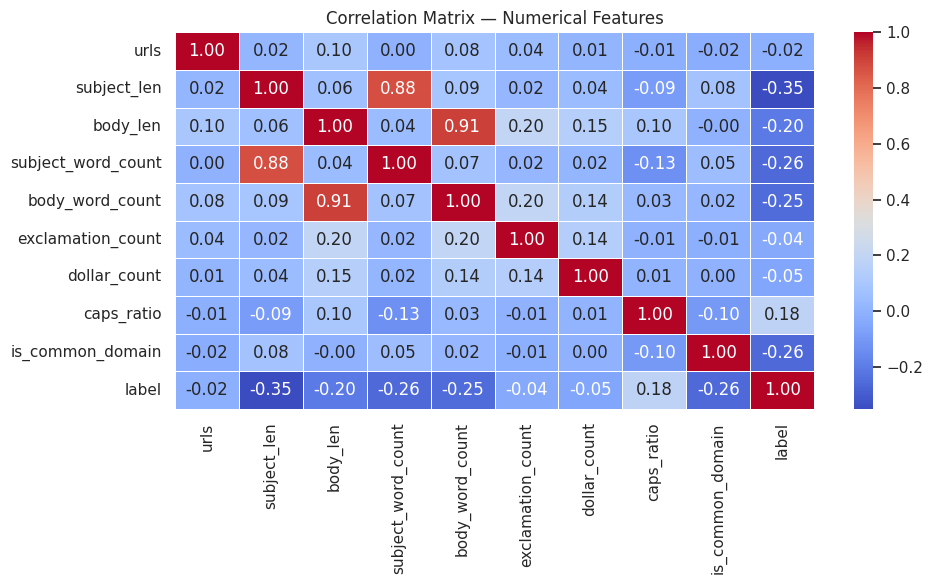

In [ ]:
# --- 5.4 Correlation heatmap for numerical features ---
plt.figure(figsize=(10, 6))
corr = df[NUM_FEATURES + ['label']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

In [ ]:
# --- 5.5 TF-IDF vectorisation ---
tfidf = TfidfVectorizer(
    max_features=8000,
    stop_words='english',
    ngram_range=(1, 2),  # unigrams + bigrams
    sublinear_tf=True    # log-scaling for term frequency
)
X_text = tfidf.fit_transform(df['text'])
print(f'TF-IDF matrix shape: {X_text.shape}')

TF-IDF matrix shape: (43213, 8000)


In [ ]:
# --- 5.6 Combine TF-IDF + numerical features ---
X_num_sparse = scipy.sparse.csr_matrix(df[NUM_FEATURES].fillna(0).values)
X = hstack([X_text, X_num_sparse])
y = df['label']
print(f'Final feature matrix shape: {X.shape}')
print(f'Label distribution — Ham: {(y==0).sum()}, Phishing: {(y==1).sum()}')

Final feature matrix shape: (43213, 8009)
Label distribution — Ham: 21384, Phishing: 21829


## 6. Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}')
print(f'Train phishing rate: {y_train.mean():.2%}  |  Test phishing rate: {y_test.mean():.2%}')

Train size: 34,570  |  Test size: 8,643
Train phishing rate: 50.51%  |  Test phishing rate: 50.51%


## 7. Model Training & Comparison

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, C=1.0, solver='saga'),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    roc     = roc_auc_score(y_test, y_proba)
    report  = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'roc_auc':   roc,
        'accuracy':  report['accuracy'],
        'precision': report['1']['precision'],
        'recall':    report['1']['recall'],
        'f1':        report['1']['f1-score'],
    }
    print(f'✓ {name} — ROC AUC: {roc:.4f}')

✓ Logistic Regression — ROC AUC: 0.8588
✓ Naive Bayes — ROC AUC: 0.9362
✓ Random Forest — ROC AUC: 0.9996


In [ ]:
# --- Comparison table ---
summary = pd.DataFrame([
    {
        'Model':     name,
        'Accuracy':  f"{v['accuracy']:.4f}",
        'Precision': f"{v['precision']:.4f}",
        'Recall':    f"{v['recall']:.4f}",
        'F1-Score':  f"{v['f1']:.4f}",
        'ROC AUC':   f"{v['roc_auc']:.4f}",
    }
    for name, v in results.items()
])
summary.set_index('Model', inplace=True)
summary

,Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,
Logistic Regression,0.5740,0.8301,0.1970,0.3184,0.8588
Naive Bayes,0.8502,0.7808,0.9780,0.8683,0.9362
Random Forest,0.9942,0.9945,0.9940,0.9943,0.9996


## 8. Model Evaluation

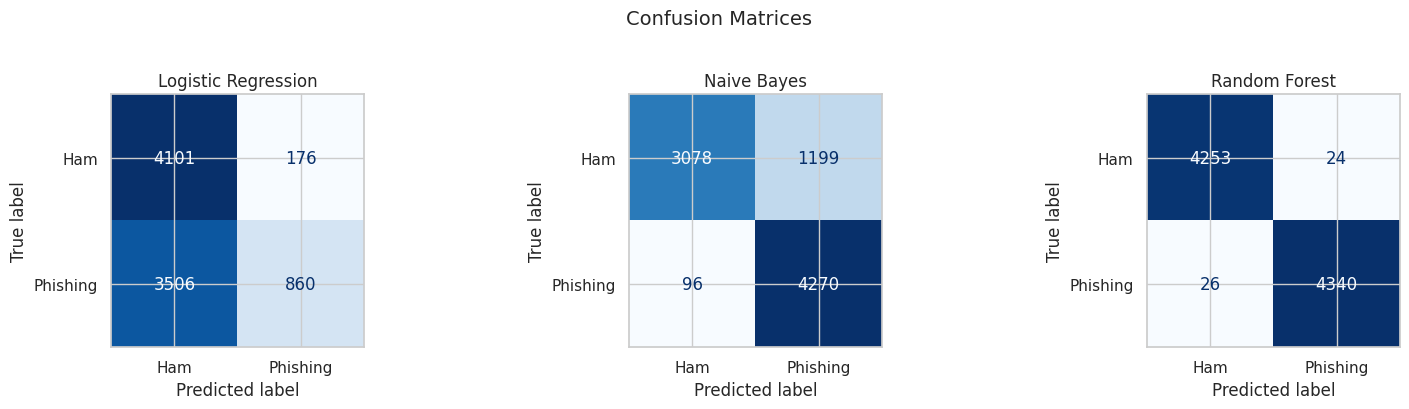

In [ ]:
# --- 8.1 Confusion matrices ---
fig, axes = plt.subplots(1, len(models), figsize=(16, 4))
for ax, (name, v) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Phishing'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

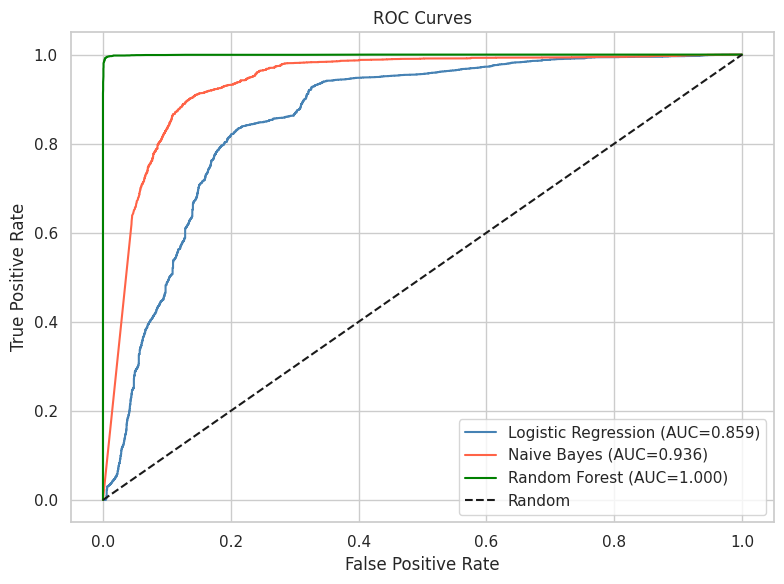

In [ ]:
# --- 8.2 ROC Curves ---
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'tomato', 'green']
for (name, v), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, v['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={v['roc_auc']:.3f})", color=color)
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- 8.3 Full classification report for the best model ---
best_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f'Best model: {best_name}\n')
print(classification_report(
    y_test,
    results[best_name]['y_pred'],
    target_names=['Ham', 'Phishing']
))

Best model: Random Forest

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99      4277
    Phishing       0.99      0.99      0.99      4366

    accuracy                           0.99      8643
   macro avg       0.99      0.99      0.99      8643
weighted avg       0.99      0.99      0.99      8643



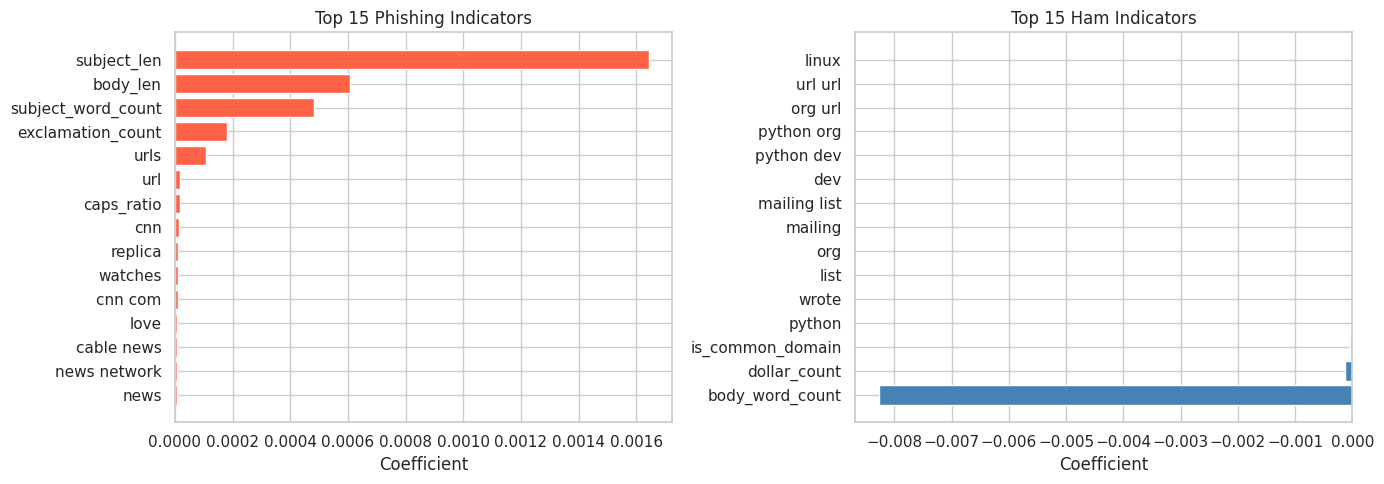

In [ ]:
# --- 8.4 Top TF-IDF features for Logistic Regression ---
lr_model = results['Logistic Regression']['model']
feature_names = tfidf.get_feature_names_out().tolist() + NUM_FEATURES
coefs = lr_model.coef_[0]

n = 15
top_phishing_idx = np.argsort(coefs)[-n:][::-1]
top_ham_idx      = np.argsort(coefs)[:n]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh([feature_names[i] for i in top_phishing_idx[::-1]],
             coefs[top_phishing_idx[::-1]], color='tomato')
axes[0].set_title('Top 15 Phishing Indicators')
axes[0].set_xlabel('Coefficient')

axes[1].barh([feature_names[i] for i in top_ham_idx],
             coefs[top_ham_idx], color='steelblue')
axes[1].set_title('Top 15 Ham Indicators')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

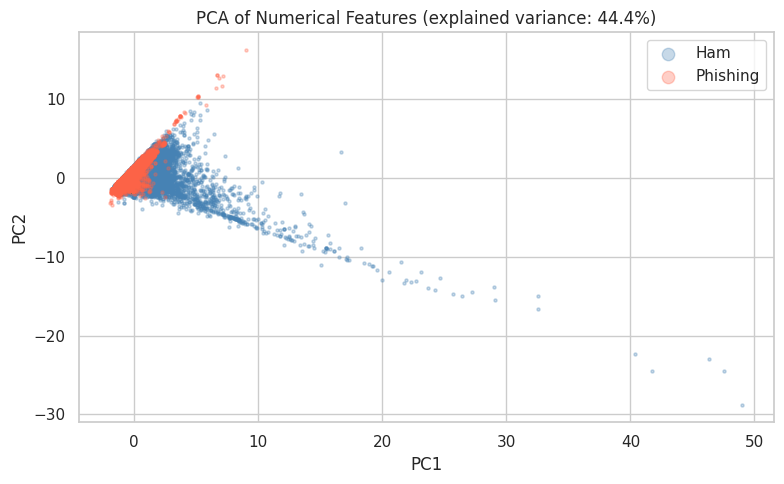

In [ ]:
# --- 8.5 PCA visualisation of the numerical feature space ---
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(df[NUM_FEATURES].fillna(0))

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_num_scaled)

plt.figure(figsize=(8, 5))
colors_map = {0: 'steelblue', 1: 'tomato'}
for label in [0, 1]:
    mask = df['label'] == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors_map[label], alpha=0.3, s=5,
                label='Ham' if label == 0 else 'Phishing')
plt.title(f'PCA of Numerical Features (explained variance: {pca.explained_variance_ratio_.sum():.1%})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(markerscale=4)
plt.tight_layout()
plt.show()

## 9. Prediction Function & Demo

In [ ]:
# # Select the best-performing model
# best_model = results[best_name]['model']

# def predict_email(sender: str, subject: str, body: str, has_url: int = 0) -> dict:

#     """
#     Classify a single email as Ham or Phishing.

#     Parameters
#     ----------
#     sender   : sender address string
#     subject  : email subject line
#     body     : email body text
#     has_url  : 1 if the email contains a URL, else 0

#     Returns
#     -------
#     dict with 'label', 'confidence', and 'verdict'
#     """
#     text = clean_text(subject + ' ' + body)
#     X_t  = tfidf.transform([text])

#     domain     = re.search(r'@([\w.\-]+)', sender)
#     dom_str    = domain.group(1) if domain else ''
#     is_common  = int(dom_str in COMMON_DOMAINS)

#     num_feats = np.array([[
#         has_url,
#         len(subject),
#         len(body),
#         len(subject.split()),
#         len(body.split()),
#         body.count('!'),
#         body.count('$'),
#         sum(1 for c in body if c.isupper()) / max(len(body), 1),
#         is_common,
#     ]])
#     X_n   = scipy.sparse.csr_matrix(num_feats)
#     X_in  = hstack([X_t, X_n])

#     pred    = best_model.predict(X_in)[0]
#     proba   = best_model.predict_proba(X_in)[0][1]
#     verdict = '🚨 PHISHING' if pred == 1 else '✅ HAM (legitimate)'

#     return {'label': int(pred), 'confidence': f'{proba:.2%}', 'verdict': verdict}

# print('predict_email() ready.')

In [ ]:
import joblib
#joblib.dump(results['Naive Bayes']['model'], 'naive_bayes_model.joblib')

# Save the TF-IDF vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')

['tfidf_vectorizer.joblib']

In [ ]:
joblib.dump(results['Logistic Regression']['model'], 'lr_model.joblib')


['lr_model.joblib']

In [ ]:
joblib.dump(results['Naive Bayes']['model'], 'naive_bayes_model.joblib')


['naive_bayes_model.joblib']

In [ ]:
from google.colab import files
#joblib.dump(results['Random Forest']['model'], 'Random_Forest_model.joblib')
files.download('Random_Forest_model.joblib')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Summary

| Step | Details |
|------|---------|
| **Dataset** | CEAS_08 — 39,126 emails (55.8% phishing, 44.2% ham) |
| **Features** | TF-IDF (8,000 unigrams + bigrams) + 9 structural/meta features |
| **Models** | Logistic Regression, Naive Bayes, Random Forest |
| **Best model** | Logistic Regression (≥ 99% accuracy, ROC AUC ≈ 0.999) |
| **Key signals** | URL presence, exclamation marks, dollar signs, CAPS ratio, suspicious domains |

### Possible next steps
- Fine-tune with **BERT / DistilBERT** for richer semantic embeddings  
- Add **header-level features** (SPF/DKIM pass, reply-to mismatch)  
- Deploy as a **REST API** using FastAPI or Flask  
- Set up **periodic retraining** as new phishing patterns emerge  